#### **Cat Dog Classification**

1.  The main objective of the problem statement is to predict whether the given image is of the Cat / Dog based on the Convolutional Neural Networks.

2.  Here in this problem, we also perform Data Augmentation where we increase the size of the training data by creating the modified versions of the existing data.


#### **Step 1: Import all the necessary libraries**

In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import os

from   tensorflow.keras.models                import Sequential
from   tensorflow.keras.layers                import Dense,Dropout,BatchNormalization,Flatten
from   tensorflow.keras.layers                import Conv2D, MaxPooling2D
from   tensorflow.keras.preprocessing.image   import ImageDataGenerator

#### **OBSERVATIONS:**

1.  Sequential -----> It forms a sequential model layer by layer

2.  Dense     ------> It forms a dense connected network

3.  Dropout --------> It is done to reduce the overfitting

4.  BatchNormalization ------> It is done to stabilize the training and speed up the neural network speed of training.

5.   Conv2D -------------->  It forms convoluted feature maps

6.   MaxPooling2D -------->  It forms reduced pooled feature maps by finding out the maximum value of the pixel size of the convoluted feature maps.

7.   ImageDataGenerator -----> It helps in generating the images.

#### **Step 2: Load the dataset**

In [258]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### **OBSERVATIONS:**

1.  mount is used to help the google colab to connect to the Google drive.

In [259]:
#### Mention the training and the testing directory
training_dir = '/content/drive/MyDrive/Cat Dog Classification/train'
testing_dir = '/content/drive/MyDrive/Cat Dog Classification/test'

#### **OBSERVATIONS:**

1.  Here the location for training and testing directory is listed.

#### **Step 3: Verify the Dataset**

In [260]:
print('Training folder')
os.listdir(training_dir)

Training folder


['cats', 'dogs']

In [261]:
print('Testing folder')
os.listdir(testing_dir)

Testing folder


['cats', 'dogs']

#### **OBSERVATIONS:**

1.  The location for the training and the testing folder is verufued.

#### **Step 4: Data Augmentation**


1.  Data Augmentation refers to the process of increasing the size of the dataset by adding the modified images of the existing dataset and increase the size of the dataset.

2.  This is done so as to prevent the overfitting.

3.  This is because the CNN Model can work on very large datasets.

In [262]:
##### Generate the new training data
train_datagen = ImageDataGenerator(
    rescale         = 1./255                                              ,
    rotation_range  = 20                                                  ,
    zoom_range      = 0.2                                                 ,
    shear_range     = 0.2                                                 ,
    horizontal_flip = True
)

#### **OBSERVATIONS:**

1.  train_datagen is done so as

    (a.)  to normalize the pixel values

    (b.)  to create the modified versions of the existing training images.

2.  This training augmentation is done so as to increase the size of the training data.

In [263]:
#### Generate the new testing data
test_datagen = ImageDataGenerator(
    rescale = 1./255
)

#### **OBSERVATIONS:**

1.  test_datagen is done so as

    (i) to normalize the pixel values

    (ii) to increase the size of the testing data

In [264]:
train_datagen

In [265]:
test_datagen

#### **OBSERVATIONS:**

1.  This training and testing data is augmented so as to increase the size of the training and the testing data.

#### **Step 5: Load Images**

In [266]:
train_generator=train_datagen.flow_from_directory(
    training_dir                                  ,
    target_size        =     (128,128)            ,
    batch_size         =        32                ,
    class_mode         =     'binary'             ,
)

Found 8005 images belonging to 2 classes.


In [267]:
train_generator

#### **OBSERVATIONS:**

1.  The training generator plays an important role in

    (a.)  loading the training images from the location where the images are stored

    (b.)  Then resizing the images into 128 * 128 pixels as the CNN requires all the inputs to be of the same size.

    (c.)  While loading the input images, it requires the input images to come in batches at a time instead of loading all the images at a time.

    (d.)  Here as the dataset involves the Cat/ Dog classification so the data augmentation generates two labels for two different classes.

    (e.) shuffle=True as the training data learns the patterns from the data instead of evaluating them.



In [268]:
test_generator=test_datagen.flow_from_directory(
    testing_dir                                   ,
    target_size        =     (128,128)            ,
    batch_size         =        32                ,
    class_mode         =     'binary'             ,
    shuffle            =      False
)

Found 2023 images belonging to 2 classes.


In [269]:
test_generator

#### **OBSERVATIONS:**

1.  The testing generator plays an important role in

    (a.)  loading the testing images from the location where the images are stored

    (b.)  Then resizing the images into 128 * 128 pixels as the CNN requires all the inputs to be of the same size.

    (c.)  While loading the input images, it requires the input images to come in batches at a time instead of loading all the images at a time.

    (d.)  Here as the dataset involves the Cat/ Dog classification so the data augmentation generates two labels for two different classes.

    (e.) shuffle=False as the testing data only performs the evaluation but do not learns the patterns from the data.



#### **Step 6: Check Classes**

In [270]:
#### check the classes of the training data
print(train_generator.class_indices)

{'cats': 0, 'dogs': 1}


In [271]:
#### check the classes of the testing data
print(test_generator.class_indices)

{'cats': 0, 'dogs': 1}


#### **OBSERVATIONS:**

1.  Both the train and test generator have the classes for

      (a.)  cats

      (b.)  dogs

#### **Step 7: Visualize the Images**

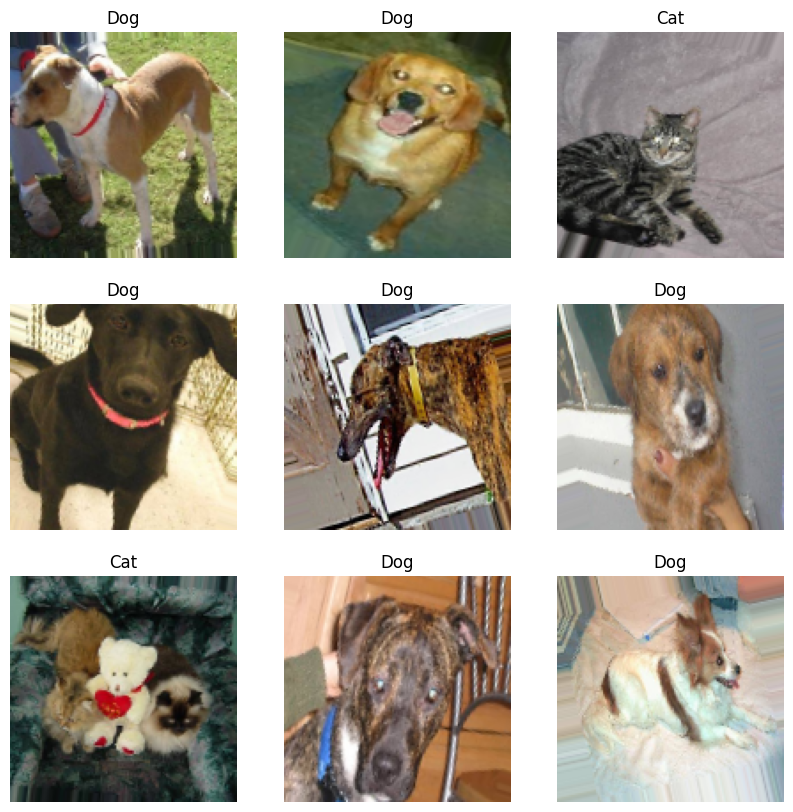

In [272]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i]==1 else "Cat")
    plt.axis("off")

plt.show()

#### **OBSERVATIONS:**

1.  Various images of Cats and Dogs are generated.

#### **Architecture Flow of CNN Model:**

Input Image

      ↓

Conv Layer

      ↓

Max Pooling

      ↓

Conv Layer

      ↓

Max Pooling

      ↓

Flatten

      ↓

Dense

      ↓
      
Output

#### **Step 8: Built the CNN Model**

In [273]:
#### built the cnn model
model = Sequential([
    #### built the first layer for CNN
    Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(pool_size=(2,2))                                                 ,

    #### built the second layer for CNN
    Conv2D(filters=64,kernel_size=(3,3),activation='relu')                        ,
    MaxPooling2D(pool_size=(2,2))                                                 ,

    #### built the third layer for CNN
    Conv2D(filters=128,kernel_size=(3,3),activation='relu')                       ,
    MaxPooling2D(pool_size=(2,2))                                                 ,

    #### perform the flattening operation
    Flatten()                                                                     ,

    #### create the dense neural network layer
    Dense(128, activation='relu')                                                 ,

    #### Add a dropout layer to reduce the overfitting
    Dropout(0.5)                                                                  ,

    #### create an output layer
    Dense(1, activation = 'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### **OBSERVATIONS:**

1.  The entire CNN Model is created with the help of the following:--

    (a.)  First layer of CNN is created

      (i) Convolution has been appied on the input image of size 128 * 128 * 3 with kernel feature map of size 3 * 3 and relu activation function has been applied on the image to increase the non-linearity of the image.

      (ii)  This is done to create the convoluted feature maps.

      (iii)  32 feature maps are produced.

      (iv) Then the Max Poolinng has been applied on the convoluted feature maps to get a pooled feature map of size 2 * 2 by selecting all the maximum values from the convoluted input image.



    (b.)  Second layer of CNN is created

      (i) Convolution has been appied on the input image with kernel feature map of size 3 * 3 and relu activation function has been applied on the image to increase the non-linearity of the image.

      (ii)  This is done to create the convoluted feature maps.

      (iii)  64 feature maps are produced.

      (iv) Then the Max Poolinng has been applied on the convoluted feature maps to get a pooled feature map of size 2 * 2 by selecting all the maximum values from the convoluted input image.



    (c.)  Third layer of CNN is created

      (i) Convolution has been appied on the input image with kernel feature map of size 3 * 3 and relu activation function has been applied on the image to increase the non-linearity of the image.

      (ii)  This is done to create the convoluted feature maps.

      (iii)  128 feature maps are produced.

      (iv) Then the Max Poolinng has been applied on the convoluted feature maps to get a pooled feature map of size 2 * 2 by selecting all the maximum values from the convoluted input image.


    (d.) Then flattening is performed to convert all the input features into 1 dimensional vectors.

    (e.) This becomes the input for the entire neural networks

    (f.) The dense neural network is created with 128 neurons in it with relu activation function applied on it to increase its non-linearity.

    (g.) Then the dropout layer has been assed to reduce the overfitting.

    (h.) Then the output layer is created with 1 neuron with sigmoid activation function applied on it to classify the Cat/Dog classification.


In [274]:
model

<Sequential name=sequential_4, built=True>

#### **Step 9: Get the summary of the model**

In [275]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

#### **OBSERVATIONS:**

1.  The above depicts about the summary of the model.

#### **Step 10: Compile the model**

In [276]:
#### Compile the model
model.compile(
    optimizer  =  'adam'                              ,
    loss       =  'binary_crossentropy'               ,
    metrics    =  ['accuracy']
)

#### **OBSERVATIONS:**

1.  The model has been made ready for the training using the following parameters:--

    (a.)  optimizer = 'adam'. It is an optimizer that updates the weights during the backpropogation.

    (b.)  loss = 'binary_crossentropy'. It is used to solve the binary classification problem.

    (c.)  metrics = ['accuracy']. It is used to evaluate the performance of the model.

#### **Step 11: Train the model**

In [277]:
#### Train the model
history=model.fit(
    train_generator                           ,
    validation_data  =  test_generator        ,
    epochs           =     10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 1689s 6s/step - accuracy: 0.5194 - loss: 0.6998 - val_accuracy: 0.5195 - val_loss: 0.6895
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 360s 1s/step - accuracy: 0.5468 - loss: 0.6881 - val_accuracy: 0.5803 - val_loss: 0.6775
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 395s 1s/step - accuracy: 0.6002 - loss: 0.6639 - val_accuracy: 0.6510 - val_loss: 0.6188
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 358s 1s/step - accuracy: 0.6516 - loss: 0.6284 - val_accuracy: 0.6728 - val_loss: 0.5970
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.6778 - loss: 0.5978 - val_accuracy: 0.7494 - val_loss: 0.5280
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 357s 1s/step - accuracy: 0.7283 - loss: 0.5416 - val_accuracy: 0.7657 - val_loss: 0.5024
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.7460 - loss: 0.5171 - val_accuracy: 0.7884 - val_loss: 0.4754
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 355s 1s/step - accuracy: 0.7605 - loss: 0.4950 - val_acc

#### **OBSERVATIONS:**


1.  The model is trained with the following parameters:--

    (a.)  train_generator that generates the training images

    (b.)  validation_data = test_generator. It is used as it performs the validation on the unseen data. This is done so that it can learn the patterns from the data.

    (c.)  epochs = 10 . The model has been trained for 10 iterations.

2. After model training, we came to the conclusion that the accuracy and the validation accuracy of the model increases but the loss and the validation loss of the model decreases.

#### **Step 12: Plot the loss and the accuracy of the model**

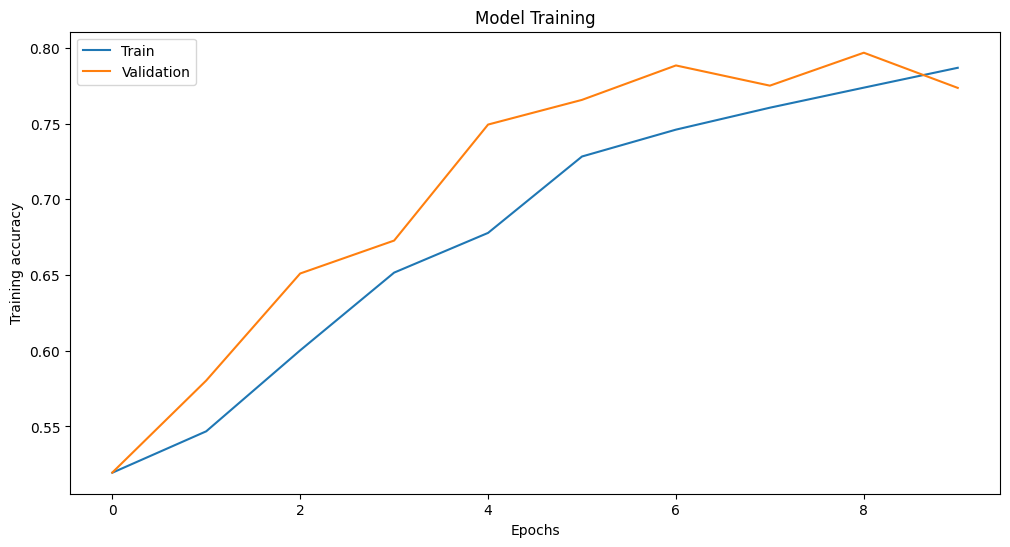

In [278]:
#### plot the accuracy
plt.figure(figsize=(12,6))

#### plot the accuracy
plt.plot(history.history['accuracy'], label = 'Training accuracy')
#### plot the validation accuracy
plt.plot(history.history['val_accuracy'], label = 'Validation accuracy')
#### get the title of the model
plt.title('Model Training')
### get the x axis of the model
plt.xlabel('Epochs')
### get the y axis of the model
plt.ylabel('Training accuracy')
### get the legend of the model
plt.legend(["Train","Validation"])
#### display the model
plt.show()

#### **OBSERVATIONS:**

1.  With the increase in the number of epochs, the accuracy and the validation accuracy of the model increases.

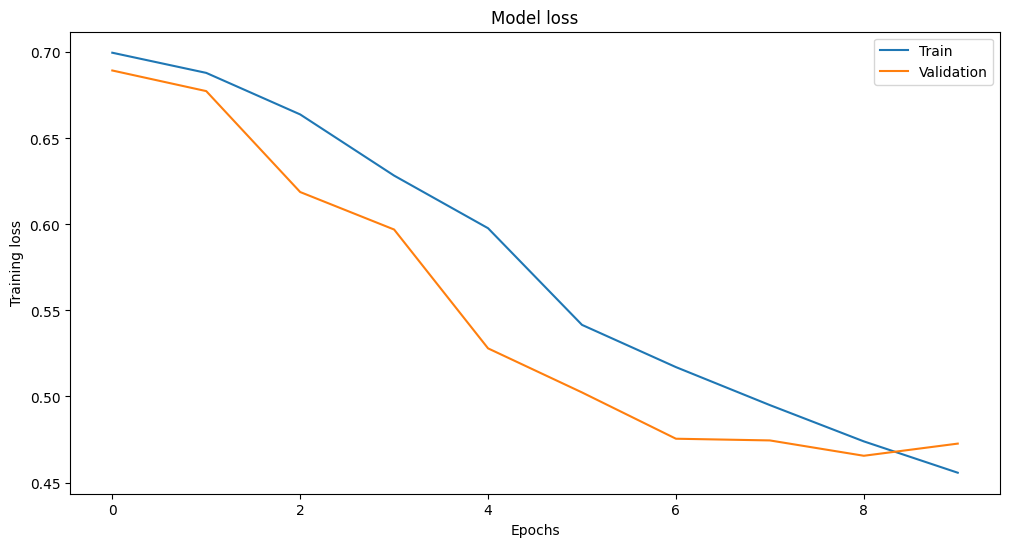

In [279]:
#### plot the loss
plt.figure(figsize=(12,6))

#### plot the accuracy
plt.plot(history.history['loss'], label = 'Training loss')
#### plot the validation accuracy
plt.plot(history.history['val_loss'], label = 'Validation loss')
#### get the title of the model
plt.title('Model loss')
### get the x axis of the model
plt.xlabel('Epochs')
### get the y axis of the model
plt.ylabel('Training loss')
### get the legend of the model
plt.legend(["Train","Validation"])
#### display the model
plt.show()

#### **OBSERVATIONS:**

1.  With the increase in the number of epochs, the loss and the validation loss of the model  reduces.

#### **Step 13: Evaluate Model**

In [280]:
loss, accuracy = model.evaluate(test_generator)

print("Loss is :", loss)
print("Accuracy is:", accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 392ms/step - accuracy: 0.7736 - loss: 0.4726
Loss is : 0.4726109206676483
Accuracy is: 0.7736035585403442


#### **OBSERVATIONS:**

1.  The accuracy of the model is 0.77 which is very high but the loss value is 0.47 which is very low.

2.  So the model is working fine.

#### **Step 14: Predict on New Image**

In [281]:
from tensorflow.keras.preprocessing import image

img_path = "/content/sample_cat.jpg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

In [282]:
#### get the prediction for the test data
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


In [283]:
prediction

array([[0.14787754]], dtype=float32)

In [284]:
if(prediction[0][0] > 0.5):
  print("Dog")
else:
  print("Cat")

Cat
